### Libraries and data loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import datetime
import itertools
import h5py
import matplotlib.dates as mdates

%matplotlib inline

In [3]:
# check tensorflow version
print("tensorflow version:", tf.__version__)
# check available gpu
gpus =  tf.config.list_physical_devices('GPU')
print("available gpus:", gpus)
# limit the gpu usage, prevent it from allocating all gpu memory for a simple model
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
# check number of cpus available
print("available cpus:", os.cpu_count())

tensorflow version: 2.20.0
available gpus: []
available cpus: 2


In [4]:
# define the data location and load data
cwd = os.getcwd()
pardir = os.path.dirname(cwd)
data_folder = os.path.join(pardir,"data","data_forecast")
data_path = os.path.join(data_folder, "forecast_dataset.hdf5")

# !change model name for different models!
model_name = 'SUNSET_forecast_2017_2019_data'
output_folder = os.path.join(pardir,"model_output", model_name)
if os.path.isdir(output_folder)==False:
    os.makedirs(output_folder)

print("data_folder:", data_folder)
print("data_path:", data_path)
print("output_folder:", output_folder)

data_folder: /data/data_forecast
data_path: /data/data_forecast/forecast_dataset.hdf5
output_folder: /model_output/SUNSET_forecast_2017_2019_data


In [5]:
import os, h5py
from google.colab import drive
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/SKIPPD"
print("BASE contents:", os.listdir(BASE))

data_path = os.path.join(BASE, "images_pv_processed.hdf5")
print("path:", data_path, "| exists:", os.path.isfile(data_path))

with h5py.File(data_path, "r") as f:
    f.visititems(lambda name, obj: print(
        f"{name:30s} " + ("group" if isinstance(obj, h5py.Group)
                           else f"dataset {obj.shape} {obj.dtype}")))

BASE contents: ['2019_pv_raw.csv', 'pv_processed_10s.csv', 'images_raw', 'images_pv_processed.hdf5', 'times_test.npy', 'times_trainval.npy', 'model_output', 'forecast_samples.npz', 'forecast_dataset.hdf5']
path: /content/drive/MyDrive/SKIPPD/images_pv_processed.hdf5 | exists: True
test                           group
test/images_log                dataset (427, 64, 64, 3) uint8
test/pv_log                    dataset (427,) float32
trainval                       group
trainval/images_log            dataset (2416, 64, 64, 3) uint8
trainval/pv_log                dataset (2416,) float32


In [6]:
# ============================================================================
#  Build forecast_dataset.hdf5 (original-repo format) from forecast_samples.npz
#  Original notebook expects: trainval/images_log (N,16,64,64,3),
#  trainval/pv_log (N,16), trainval/pv_pred (N,) — and same under test/.
# ============================================================================
import os, numpy as np, h5py

BASE = "/content/drive/MyDrive/SKIPPD"
d = np.load(os.path.join(BASE, "forecast_samples.npz"))

# your npz splits train/val/test; the original format uses trainval + test.
# combine train+val back into one "trainval" group.
Xi_tv = np.concatenate([d["Xi_train"], d["Xi_val"]], axis=0)   # (N,16,64,64,3)
Xp_tv = np.concatenate([d["Xp_train"], d["Xp_val"]], axis=0)   # (N,16)
y_tv  = np.concatenate([d["y_train"],  d["y_val"]],  axis=0)   # (N,)

out = os.path.join(BASE, "forecast_dataset.hdf5")
with h5py.File(out, "w") as f:
    g = f.create_group("trainval")
    g.create_dataset("images_log", data=Xi_tv.astype("uint8"), compression="gzip")
    g.create_dataset("pv_log",     data=Xp_tv.astype("float32"))
    g.create_dataset("pv_pred",    data=y_tv.astype("float32"))
    g = f.create_group("test")
    g.create_dataset("images_log", data=d["Xi_test"].astype("uint8"), compression="gzip")
    g.create_dataset("pv_log",     data=d["Xp_test"].astype("float32"))
    g.create_dataset("pv_pred",    data=d["y_test"].astype("float32"))

print("Wrote", out)
with h5py.File(out, "r") as f:
    f.visititems(lambda n, o: print(" ", n, getattr(o, "shape", "")))

Wrote /content/drive/MyDrive/SKIPPD/forecast_dataset.hdf5
  test 
  test/images_log (367, 16, 64, 64, 3)
  test/pv_log (367, 16)
  test/pv_pred (367,)
  trainval 
  trainval/images_log (1949, 16, 64, 64, 3)
  trainval/pv_log (1949, 16)
  trainval/pv_pred (1949,)


In [7]:
import os, h5py, numpy as np
BASE = "/content/drive/MyDrive/SKIPPD"
data_folder = BASE
data_path   = os.path.join(BASE, "forecast_dataset.hdf5")   # must be the FORECAST file
forecast_dataset = h5py.File(data_path, "r")                # keep it open for later cells

print('-'*50)
img_side_len      = forecast_dataset['trainval']['images_log'].shape[2]
num_log_term      = forecast_dataset['trainval']['images_log'].shape[1]
num_color_channel = forecast_dataset['trainval']['images_log'].shape[4]
image_input_dim   = [img_side_len, img_side_len, num_log_term*num_color_channel]
print("input image dimension:", image_input_dim)

times_trainval = np.load(os.path.join(data_folder, "times_trainval.npy"), allow_pickle=True)
print("times_trainval.shape:", times_trainval.shape)

--------------------------------------------------
input image dimension: [64, 64, 48]
times_trainval.shape: (2416,)


In [8]:
import os

print("Files in /content/drive/MyDrive/SKIPPD:")
for item in os.listdir(BASE):
    print(item)

Files in /content/drive/MyDrive/SKIPPD:
2019_pv_raw.csv
pv_processed_10s.csv
images_raw
images_pv_processed.hdf5
times_test.npy
times_trainval.npy
model_output
forecast_samples.npz
forecast_dataset.hdf5


In [9]:
# read through the dataset once in order to cache it (not stored in memory)
import time

# take the count from the DATASET, not from times_trainval (they can differ)
num_samples = forecast_dataset['trainval']['images_log'].shape[0]
num_batches = 5
batch_size  = max(1, num_samples // num_batches)
indices     = np.arange(num_samples)

print('-'*50)
print(f'data reading start... ({num_samples} samples)')
for i in range(num_batches):
    start_time = time.time()
    start_idx = i * batch_size
    if start_idx >= num_samples:
        break
    # last batch takes everything remaining
    end_idx = num_samples if i == num_batches - 1 else min(start_idx + batch_size, num_samples)
    idxs = indices[start_idx:end_idx]
    if len(idxs) == 0:
        break

    _ = forecast_dataset['trainval']['images_log'][idxs]
    _ = forecast_dataset['trainval']['pv_log'][idxs]
    _ = forecast_dataset['trainval']['pv_pred'][idxs]

    end_time = time.time()
    print("batch {0} samples: {1} to {2}, {3:.2f}% finished, processing time {4:.2f}s"
          .format(i+1, idxs[0], idxs[-1], (idxs[-1]+1)/num_samples*100, end_time-start_time))

forecast_dataset.close()

--------------------------------------------------
data reading start... (1949 samples)
batch 1 samples: 0 to 388, 19.96% finished, processing time 1.29s
batch 2 samples: 389 to 777, 39.92% finished, processing time 1.17s
batch 3 samples: 778 to 1166, 59.88% finished, processing time 0.94s
batch 4 samples: 1167 to 1555, 79.84% finished, processing time 1.17s
batch 5 samples: 1556 to 1948, 100.00% finished, processing time 0.94s


### Input data pipeline helper functions

In [10]:
# day block shuffling of the time stamps, and return shuffled indices
def day_block_shuffle(times_trainval):

    # Only keep the date of each time point
    dates_trainval = np.zeros_like(times_trainval, dtype=datetime.date)
    for i in range(len(times_trainval)):
        dates_trainval[i] = times_trainval[i].date()

    # Chop the indices into blocks, so that each block contains the indices of the same day
    unique_dates = np.unique(dates_trainval)
    blocks = []
    for i in range(len(unique_dates)):
        blocks.append(np.where(dates_trainval == unique_dates[i])[0])

    # shuffle the blocks, and chain it back together
    np.random.seed(1)
    np.random.shuffle(blocks)
    shuffled_indices = np.asarray(list(itertools.chain.from_iterable(blocks)))

    return shuffled_indices

In [11]:
# a cross validation generator function for spliting the dayblock shuffled indices into training and validation
def cv_split(split_data, fold_index, num_fold):
    '''
    input:
    split_data: the dayblock shuffled indices to be splitted
    fold_index: the ith fold chosen as the validation, used for generating the seed for random shuffling
    num_fold: N-fold cross validation
    output:
    data_train: the train data indices
    data_val: the validation data indices
    '''
    # randomly divides into a training set and a validation set
    num_samples = len(split_data)
    indices = np.arange(num_samples)

    # finding training and validation indices
    val_mask = np.zeros(len(indices), dtype=bool)
    val_mask[int(fold_index / num_fold * num_samples):int((fold_index + 1) / num_fold * num_samples)] = True
    val_indices = indices[val_mask]
    train_indices = indices[np.logical_not(val_mask)]

    # shuffle indices
    np.random.seed(fold_index)
    np.random.shuffle(train_indices)
    np.random.shuffle(val_indices)

    data_train = split_data[train_indices]
    data_val = split_data[val_indices]

    return data_train,data_val

In [12]:
def process_image(image_data):
    '''
    image data processing: reshaping and normalization
    '''
    ## reshape the image tensor from [None,16,64,64,3] to [None,64,64,48]
    image_data = tf.transpose(image_data,perm=[0,2,3,1,4])
    image_data = tf.reshape(image_data, [image_data.shape[0],image_data.shape[1],image_data.shape[2],-1])

    ## normalize the image to [0,1]
    image_data = tf.image.convert_image_dtype(image_data, tf.float32)

    return image_data

In [13]:
# a mapping function from the indices to the corresponding features and labels
def data_loader(hdf5_data_path,sample_idx,batch_size=256):
    '''
    input:
    hdf5_data_path: path to hdf5 data file
    sample_idx:
        for training and validation:
            dayblock shuffled indices with cross-validation split into training and validation
            either training or validation indices will be input
        for testing: the indices are not shuffled
    is_trainval: a flag, True for trainig and validation
    output:
    dataset: dataset for training, validation
    '''

    def mapping_func_py(hdf5_data_path,sample_idx):
        '''
        mapping indices to corresponding images and pviance data in hdf5 (python expression)
        '''
        # convert EagerTensor to str or numpy array
        hdf5_data_path = hdf5_data_path.numpy().decode()
        # sort the sample indices as hdf5 requires increasing order index for data retrieval
        sample_idx = sorted(sample_idx.numpy())

        with h5py.File(hdf5_data_path,'r') as f:

            # read in the data
            images_log = f['trainval']['images_log'][sample_idx]
            pv_log = f['trainval']['pv_log'][sample_idx]
            pv_pred = f['trainval']['pv_pred'][sample_idx]

            # process image data
            images_log = process_image(images_log)

            # convert pv data to tf.tensor
            pv_log = tf.convert_to_tensor(pv_log, dtype=tf.float32)
            pv_pred = tf.convert_to_tensor(pv_pred, dtype=tf.float32)

            return images_log, pv_log, pv_pred

    def mapping_func_tf(hdf5_data_path,sample_idx):
        '''
        a wrapper mapping function to get the nested data structure
        the output type of tf.py_function cannot be a nested sequence when using a tf.py_function with the tf.data API
        '''
        images_log, pv_log, pv_pred = tf.py_function(func=mapping_func_py,
                                                           inp=[hdf5_data_path, sample_idx],
                                                           Tout=(tf.float32, tf.float32, tf.float32))
        return (images_log, pv_log), pv_pred


    # create the indices dataset
    idx_ds = tf.data.Dataset.from_tensor_slices(sample_idx)
    # shuffle and batch the indices
    idx_ds = idx_ds.shuffle(buffer_size = idx_ds.cardinality().numpy(),seed=0)
    idx_ds = idx_ds.batch(batch_size).repeat().prefetch(tf.data.experimental.AUTOTUNE)

    # indices dataset mapping to images and pviance data
    # returning dataset with the following nested structure: (images_log, pv_log), pv_pred
    dataset = idx_ds.map(lambda x: mapping_func_tf(hdf5_data_path,x),
                         num_parallel_calls=tf.data.experimental.AUTOTUNE)

    return dataset

### Model architecture

In [14]:
# define model characteristics
num_filters = 24
kernel_size = [3,3]
pool_size = [2,2]
strides = 2
dense_size = 1024
drop_rate = 0.4

# define training time parameters
num_epochs    = 40
num_fold      = 3
batch_size    = 64
learning_rate = 1e-4

In [15]:
# define the model architecture using tf.keras API
def sunset_model():
    ## input
    ### input image logs with shape (64,64,24/48)
    x_in = keras.Input(shape=image_input_dim)
    ### input pv output history logs with shape (num_log_term,)
    x2_in = keras.Input(shape=(num_log_term,))          # <-- fixed: tuple

    ## 1st convolution block
    x = keras.layers.Conv2D(num_filters, kernel_size, padding="same", activation='relu')(x_in)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D(pool_size, strides)(x)

    ## 2nd convolution block
    x = keras.layers.Conv2D(num_filters*2, kernel_size, padding="same", activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D(pool_size, strides)(x)

    ## two fully connected nets
    x = keras.layers.Flatten()(x)
    x = keras.layers.Concatenate(axis=1)([x, x2_in])
    x = keras.layers.Dense(dense_size, activation='relu')(x)
    x = keras.layers.Dropout(drop_rate)(x)
    x = keras.layers.Dense(dense_size, activation='relu')(x)
    x = keras.layers.Dropout(drop_rate)(x)

    ## regression to prediction target
    y_out = keras.layers.Dense(units=1)(x)
    return keras.Model(inputs=[x_in, x2_in], outputs=y_out)

sunset_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │     10,392 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     10,416 │ max_pooling2d[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12288)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12304)     │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │ 12,600,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  1,049,600 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      1,025 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,672,041 (52.15 MB)

 Trainable params: 13,671,897 (52.15 MB)

 Non-trainable params: 144 (576.00 B)

### Model training and validation

In [16]:
# --- load forecast data in memory (run once, before the training loop) ---
d = np.load(os.path.join(BASE, "forecast_samples.npz"))

def stack_seq(Xi):                                  # (N,16,64,64,3) -> (N,64,64,48)
    Xi = np.transpose(Xi, (0, 2, 3, 1, 4))
    return Xi.reshape(Xi.shape[0], Xi.shape[1], Xi.shape[2], -1)

# combine train+val into one "trainval" pool; CV re-splits it per fold
Xi_all = stack_seq(np.concatenate([d["Xi_train"], d["Xi_val"]], axis=0))
Xp_all = np.concatenate([d["Xp_train"], d["Xp_val"]], axis=0).astype("float32")
y_all  = np.concatenate([d["y_train"],  d["y_val"]],  axis=0).astype("float32")
print("trainval pool:", Xi_all.shape, Xp_all.shape, y_all.shape)

trainval pool: (1949, 64, 64, 48) (1949, 16) (1949,)


Repetition 1 model training started ...
Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 66.1591
Epoch 1: val_loss improved from None to 33.52241, saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_1/best_model_repitition_1.keras

Epoch 1: finished saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_1/best_model_repitition_1.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 748ms/step - loss: 33.8400 - val_loss: 33.5224
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - loss: 8.7764
Epoch 2: val_loss improved from 33.52241 to 27.40912, saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_1/best_model_repitition_1.keras

Epoch 2: finished saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_1/best_model_repitition_1.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 733ms/step - loss: 7.8485 - val_loss: 27.4091
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - loss: 6.9515
Epoch 3: val_loss improved from 27.40912 to 2

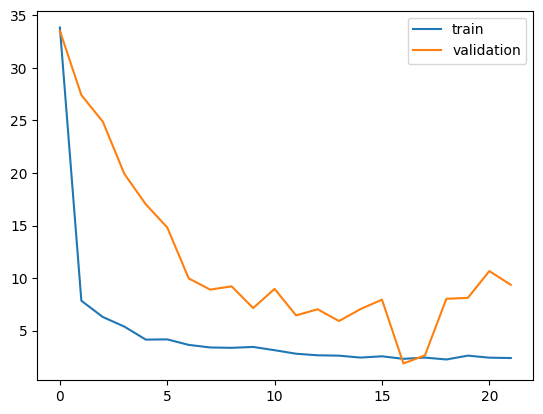

Repetition 2 model training started ...
Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - loss: 64.5538
Epoch 1: val_loss improved from None to 61.81460, saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_2/best_model_repitition_2.keras

Epoch 1: finished saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_2/best_model_repitition_2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 756ms/step - loss: 35.3910 - val_loss: 61.8146
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - loss: 9.1606
Epoch 2: val_loss improved from 61.81460 to 60.24135, saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_2/best_model_repitition_2.keras

Epoch 2: finished saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_2/best_model_repitition_2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 770ms/step - loss: 8.5364 - val_loss: 60.2414
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - loss: 7.0530
Epoch 3: val_loss improved from 60.24135 to 3

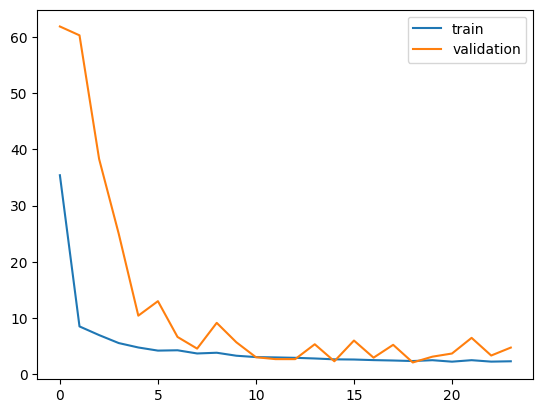

Repetition 3 model training started ...
Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - loss: 73.3676
Epoch 1: val_loss improved from None to 25.35667, saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_3/best_model_repitition_3.keras

Epoch 1: finished saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_3/best_model_repitition_3.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 816ms/step - loss: 37.0467 - val_loss: 25.3567
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - loss: 9.7584
Epoch 2: val_loss improved from 25.35667 to 22.50375, saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_3/best_model_repitition_3.keras

Epoch 2: finished saving model to /model_output/SUNSET_forecast_2017_2019_data/repetition_3/best_model_repitition_3.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 791ms/step - loss: 9.4645 - val_loss: 22.5037
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 7.0280
Epoch 3: val_loss improved from 22.50375 to 2

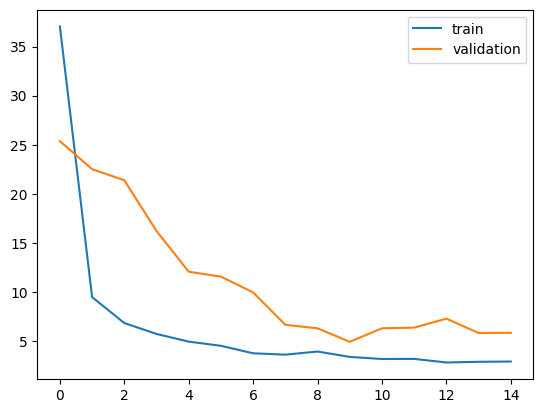

In [17]:
# initialize loss history
train_loss_hist, val_loss_hist = [], []

n = len(y_all)
for i in range(num_fold):
    keras.backend.clear_session()
    model = sunset_model()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss='mse')
    print('Repetition {0} model training started ...'.format(i+1))

    save_directory = os.path.join(output_folder, 'repetition_'+str(i+1))
    os.makedirs(save_directory, exist_ok=True)

    # day-block-style CV split, but on in-memory array indices
    idx = np.arange(n)
    np.random.seed(i); np.random.shuffle(idx)
    val_mask = np.zeros(n, dtype=bool)
    val_mask[int(i/num_fold*n):int((i+1)/num_fold*n)] = True
    idx_val, idx_tr = idx[val_mask], idx[~val_mask]

    earlystop = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5,
                                              restore_best_weights=True)
    checkpoint = keras.callbacks.ModelCheckpoint(
        os.path.join(save_directory, 'best_model_repitition_'+str(i+1)+'.keras'),   # .keras, not .h5
        monitor='val_loss', mode='min', save_best_only=True, verbose=1)

    history = model.fit(
        [Xi_all[idx_tr], Xp_all[idx_tr]], y_all[idx_tr],
        validation_data=([Xi_all[idx_val], Xp_all[idx_val]], y_all[idx_val]),
        epochs=num_epochs, batch_size=batch_size,
        callbacks=[earlystop, checkpoint], verbose=1)

    train_loss_hist.append(history.history['loss'])
    val_loss_hist.append(history.history['val_loss'])

    plt.plot(train_loss_hist[i], label='train')
    plt.plot(val_loss_hist[i], label='validation')
    plt.legend(); plt.show()

    np.save(os.path.join(output_folder, 'train_loss_hist.npy'), np.array(train_loss_hist, dtype=object))
    np.save(os.path.join(output_folder, 'val_loss_hist.npy'),   np.array(val_loss_hist,   dtype=object))

In [18]:
# summary of training and validation results
best_train_loss_MSE = np.zeros(num_fold)
best_val_loss_MSE = np.zeros(num_fold)

for i in range(num_fold):
    best_val_loss_MSE[i] = np.min(val_loss_hist[i])
    idx = np.argmin(val_loss_hist[i])
    best_train_loss_MSE[i] = train_loss_hist[i][idx]
    print('Model {0}  -- train loss: {1:.2f}, validation loss: {2:.2f} (RMSE)'.format(i+1, np.sqrt(best_train_loss_MSE[i]), np.sqrt(best_val_loss_MSE[i])))
print('The mean train loss (RMSE) for all models is {0:.2f}'.format(np.mean(np.sqrt(best_train_loss_MSE))))
print('The mean validation loss (RMSE) for all models is {0:.2f}'.format(np.mean(np.sqrt(best_val_loss_MSE))))

Model 1  -- train loss: 1.52, validation loss: 1.37 (RMSE)
Model 2  -- train loss: 1.54, validation loss: 1.46 (RMSE)
Model 3  -- train loss: 1.84, validation loss: 2.22 (RMSE)
The mean train loss (RMSE) for all models is 1.63
The mean validation loss (RMSE) for all models is 1.68


In [28]:
model_save_path = os.path.join(BASE, "model_output", model_name, 'final_sunset_model.keras')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
model.save(model_save_path)
print(f"Final model saved to {model_save_path}")

Final model saved to /content/drive/MyDrive/SKIPPD/model_output/SUNSET_forecast_2017_2019_data/final_sunset_model.keras


In [33]:
import os

# Define the persistent save path in Google Drive
persistent_model_path = '/content/drive/MyDrive/SKIPPD/model_output/SUNSET_forecast_2017_2019_data/sunset_deployment_model.keras'

# Ensure the directory exists
os.makedirs(os.path.dirname(persistent_model_path), exist_ok=True)

# Save the model
model.save(persistent_model_path)

print(f"Model successfully saved to: {persistent_model_path}")
print("You can now load this model in a new notebook using: model = tf.keras.models.load_model('" + persistent_model_path + "')")

Model successfully saved to: /content/drive/MyDrive/SKIPPD/model_output/SUNSET_forecast_2017_2019_data/sunset_deployment_model.keras
You can now load this model in a new notebook using: model = tf.keras.models.load_model('/content/drive/MyDrive/SKIPPD/model_output/SUNSET_forecast_2017_2019_data/sunset_deployment_model.keras')


### Model testing

In [19]:
# load testing data
times_test = np.load(os.path.join(data_folder,"times_test.npy"),allow_pickle=True)
print("times_test.shape:", times_test.shape)

with h5py.File(data_path,'r') as f:

    # read in the data
    images_log_test = f['test']['images_log'][...]
    pv_log_test = f['test']['pv_log'][...]
    pv_pred_test = f['test']['pv_pred'][...]

# process image data
images_log_test = np.transpose(images_log_test,axes=[0,2,3,1,4])
images_log_test = np.reshape(images_log_test, [images_log_test.shape[0],images_log_test.shape[1],images_log_test.shape[2],-1])
images_log_test = (images_log_test/255.0).astype('float32')

print("images_log_test.shape:",images_log_test.shape)
print("pv_log_test.shape:",pv_log_test.shape)
print("pv_pred_test.shape:",pv_pred_test.shape)

times_test.shape: (427,)
images_log_test.shape: (367, 64, 64, 48)
pv_log_test.shape: (367, 16)
pv_pred_test.shape: (367,)


In [20]:
import glob

# --- load test data from your npz (once) ---
d = np.load(os.path.join(BASE, "forecast_samples.npz"))
def stack_seq(Xi):
    Xi = np.transpose(Xi, (0, 2, 3, 1, 4))
    return Xi.reshape(Xi.shape[0], Xi.shape[1], Xi.shape[2], -1)
images_log_test = stack_seq(d["Xi_test"])
pv_log_test     = d["Xp_test"].astype("float32")
pv_pred_test    = d["y_test"].astype("float32")

# --- find the .keras models you actually trained ---
model_paths = sorted(glob.glob(os.path.join(output_folder, "repetition_*",
                                            "best_model_repitition_*.keras")))
assert model_paths, f"No models found in {output_folder} — run the training cell first."
n_models = len(model_paths)
print(f"Found {n_models} trained models.")

prediction = np.zeros((n_models, len(pv_pred_test)))
for i, model_path in enumerate(model_paths):
    print(f"loading model {i+1}/{n_models} ...")
    model = keras.models.load_model(model_path)
    prediction[i] = np.squeeze(model.predict([images_log_test, pv_log_test],
                                             batch_size=200, verbose=0))

np.save(os.path.join(output_folder, 'test_predictions.npy'), prediction)

# ensemble mean
print('-'*50)
prediction_ensemble = np.clip(np.mean(prediction, axis=0), 0, None)
rmse = np.sqrt(np.mean((prediction_ensemble - pv_pred_test)**2))
mae  = np.mean(np.abs(prediction_ensemble - pv_pred_test))
print(f"Ensemble test RMSE: {rmse:.3f} kW")
print(f"Ensemble test MAE : {mae:.3f} kW")

Found 3 trained models.
loading model 1/3 ...
loading model 2/3 ...
loading model 3/3 ...


--------------------------------------------------
Ensemble test RMSE: 5.247 kW
Ensemble test MAE : 4.103 kW


In [21]:
lim = np.quantile(pv_pred_test, 0.5)
mask = pv_pred_test > lim

prediction_ensemble_sunny  = prediction_ensemble[mask]
prediction_ensemble_cloudy = prediction_ensemble[~mask]
pv_pred_test_sunny  = pv_pred_test[mask]
pv_pred_test_cloudy = pv_pred_test[~mask]

# RMSE for sunny and cloudy days individually
rmse_sunny = np.sqrt(np.mean(np.square((prediction_ensemble_sunny-pv_pred_test_sunny))))
rmse_cloudy = np.sqrt(np.mean(np.square((prediction_ensemble_cloudy-pv_pred_test_cloudy))))
rmse_overall = np.sqrt((rmse_sunny**2*len(pv_pred_test_sunny)+rmse_cloudy**2*len(pv_pred_test_cloudy))/(len(pv_pred_test)))

print("test set sunny days RMSE: {0:.3f}".format(rmse_sunny))
print("test set cloudy days RMSE: {0:.3f}".format(rmse_cloudy))
print("test set overall RMSE: {0:.3f}".format(rmse_overall))

test set sunny days RMSE: 5.432
test set cloudy days RMSE: 5.056
test set overall RMSE: 5.247


In [22]:
# MAE for sunny and cloudy days individually
mae_sunny = np.mean(np.abs((prediction_ensemble_sunny-pv_pred_test_sunny)))
mae_cloudy = np.mean(np.abs((prediction_ensemble_cloudy-pv_pred_test_cloudy)))
mae_overall = (mae_cloudy*len(pv_pred_test_cloudy) + mae_sunny*len(pv_pred_test_sunny))/(len(pv_pred_test))

print("test set sunny days MAE: {0:.3f}".format(mae_sunny))
print("test set cloudy days MAE: {0:.3f}".format(mae_cloudy))
print("test set overall MAE: {0:.3f}".format(mae_overall))

test set sunny days MAE: 4.502
test set cloudy days MAE: 3.706
test set overall MAE: 4.103


In [23]:
# Forecast skill vs. SIMPLE PERSISTENCE (no Relative_op_func, no timestamps needed).
# Persistence = assume PV in 15 min equals the last known PV (last value of pv_log history).
per_prediction = pv_log_test[:, -1]          # last PV reading in each sample's history

per_prediction_sunny  = per_prediction[mask]
per_prediction_cloudy = per_prediction[~mask]

per_rmse_sunny   = np.sqrt(np.mean((per_prediction_sunny  - pv_pred_test_sunny )**2))
per_rmse_cloudy  = np.sqrt(np.mean((per_prediction_cloudy - pv_pred_test_cloudy)**2))
per_rmse_overall = np.sqrt(np.mean((per_prediction        - pv_pred_test       )**2))
print("persistence RMSE — sunny : {0:.3f} kW".format(per_rmse_sunny))
print("persistence RMSE — cloudy: {0:.3f} kW".format(per_rmse_cloudy))
print("persistence RMSE — overall: {0:.3f} kW".format(per_rmse_overall))

# model RMSE overall (in case not already defined)
rmse_overall = np.sqrt(np.mean((prediction_ensemble - pv_pred_test)**2))

# forecast skill = 1 - model_rmse / persistence_rmse  (positive % = beats persistence)
fs_sunny   = 1 - rmse_sunny  / per_rmse_sunny
fs_cloudy  = 1 - rmse_cloudy / per_rmse_cloudy
fs_overall = 1 - rmse_overall / per_rmse_overall
print("\nforecast skill — sunny : {0:.2f}%".format(fs_sunny*100))
print("forecast skill — cloudy: {0:.2f}%".format(fs_cloudy*100))
print("forecast skill — overall: {0:.2f}%".format(fs_overall*100))

persistence RMSE — sunny : 5.883 kW
persistence RMSE — cloudy: 5.320 kW
persistence RMSE — overall: 5.608 kW

forecast skill — sunny : 7.67%
forecast skill — cloudy: 4.95%
forecast skill — overall: 6.43%


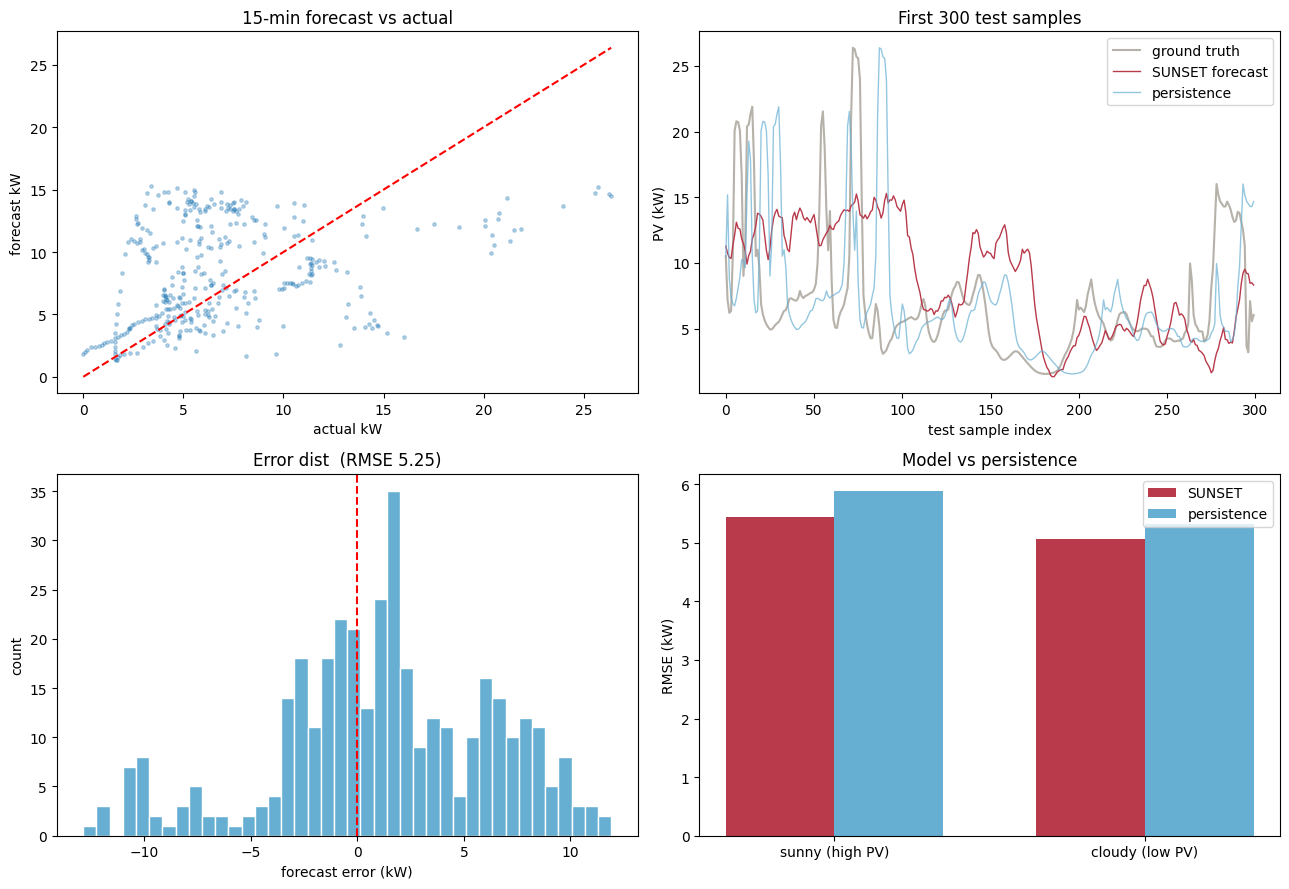

In [24]:
# Forecast visualization for timestamp-free forecast samples.
# (The original per-day time-series can't run: forecast samples have no matching timestamps.)
import matplotlib.pyplot as plt

y_true  = pv_pred_test
y_fore  = prediction_ensemble
y_pers  = per_prediction

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1) predicted vs actual scatter
ax[0,0].scatter(y_true, y_fore, s=6, alpha=0.3)
lim = [0, max(y_true.max(), y_fore.max())]
ax[0,0].plot(lim, lim, 'r--')
ax[0,0].set_xlabel("actual kW"); ax[0,0].set_ylabel("forecast kW")
ax[0,0].set_title("15-min forecast vs actual")

# 2) a slice of the test series: forecast vs actual vs persistence
n = min(300, len(y_true))
ax[0,1].plot(y_true[:n], color='#B6B1A9', label='ground truth')
ax[0,1].plot(y_fore[:n], color='#B83A4B', lw=1, label='SUNSET forecast')
ax[0,1].plot(y_pers[:n], color='#67AFD2', lw=1, alpha=0.7, label='persistence')
ax[0,1].set_xlabel("test sample index"); ax[0,1].set_ylabel("PV (kW)")
ax[0,1].set_title("First 300 test samples"); ax[0,1].legend()

# 3) error distribution
err = y_fore - y_true
ax[1,0].hist(err, bins=40, color='#67AFD2', edgecolor='white')
ax[1,0].axvline(0, color='r', ls='--')
ax[1,0].set_xlabel("forecast error (kW)"); ax[1,0].set_ylabel("count")
ax[1,0].set_title(f"Error dist  (RMSE {np.sqrt(np.mean(err**2)):.2f})")

# 4) sunny/cloudy (by power level) RMSE bar
labels = ['sunny (high PV)', 'cloudy (low PV)']
model_rmse = [np.sqrt(np.mean((prediction_ensemble_sunny  - pv_pred_test_sunny )**2)),
              np.sqrt(np.mean((prediction_ensemble_cloudy - pv_pred_test_cloudy)**2))]
pers_rmse  = [np.sqrt(np.mean((per_prediction_sunny  - pv_pred_test_sunny )**2)),
              np.sqrt(np.mean((per_prediction_cloudy - pv_pred_test_cloudy)**2))]
x = np.arange(2); w = 0.35
ax[1,1].bar(x-w/2, model_rmse, w, label='SUNSET', color='#B83A4B')
ax[1,1].bar(x+w/2, pers_rmse,  w, label='persistence', color='#67AFD2')
ax[1,1].set_xticks(x); ax[1,1].set_xticklabels(labels)
ax[1,1].set_ylabel("RMSE (kW)"); ax[1,1].set_title("Model vs persistence"); ax[1,1].legend()

plt.tight_layout(); plt.show()

  FORECAST CLASSIFICATION METRICS  (edges kW: [ 0.   4.7  7.2 26.4])
  Accuracy      : 0.482
  Precision (w) : 0.491   Recall (w): 0.482   F1 (w): 0.467
  F1 (macro)    : 0.466

              precision    recall  f1_score  support
Low            0.609000  0.459000  0.523000    122.0
Medium         0.416000  0.262000  0.322000    122.0
High           0.449000  0.724000  0.555000    123.0
macro avg      0.491258  0.481630  0.466497    367.0
weighted avg   0.491145  0.482289  0.466736    367.0

sklearn classification_report:
              precision    recall  f1-score   support

         Low       0.61      0.46      0.52       122
      Medium       0.42      0.26      0.32       122
        High       0.45      0.72      0.55       123

    accuracy                           0.48       367
   macro avg       0.49      0.48      0.47       367
weighted avg       0.49      0.48      0.47       367



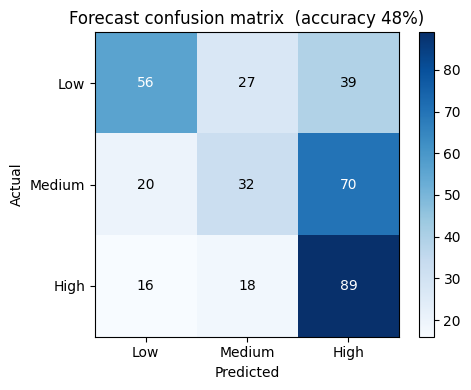

In [25]:
# ============================================================================
#  Forecast — classification metrics (accuracy, precision, recall, F1) + confusion matrix
#  The model outputs continuous kW, so we bin power into Low / Medium / High
#  classes and evaluate the forecast as a classification of those bands.
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_recall_fscore_support)

y_true = pv_pred_test                 # actual PV (kW)
y_pred = prediction_ensemble          # forecast PV (kW)

# --- bin into 3 power classes by tertiles (equal-frequency) ---
edges  = np.quantile(y_true, [0, 1/3, 2/3, 1.0])
labels = ["Low", "Medium", "High"]
to_class = lambda v: np.clip(np.digitize(v, edges[1:-1]), 0, 2)
t_cls, p_cls = to_class(y_true), to_class(y_pred)

# --- metrics ---
acc = accuracy_score(t_cls, p_cls)
prec, rec, f1, sup = precision_recall_fscore_support(t_cls, p_cls, labels=[0,1,2], zero_division=0)
mac = precision_recall_fscore_support(t_cls, p_cls, average="macro",    zero_division=0)
wgt = precision_recall_fscore_support(t_cls, p_cls, average="weighted", zero_division=0)

print("="*52)
print(f"  FORECAST CLASSIFICATION METRICS  (edges kW: {np.round(edges,1)})")
print("="*52)
print(f"  Accuracy      : {acc:.3f}")
print(f"  Precision (w) : {wgt[0]:.3f}   Recall (w): {wgt[1]:.3f}   F1 (w): {wgt[2]:.3f}")
print(f"  F1 (macro)    : {mac[2]:.3f}\n")

tbl = pd.DataFrame({"precision":prec, "recall":rec, "f1_score":f1, "support":sup},
                   index=labels).round(3)
tbl.loc["macro avg"]    = [mac[0], mac[1], mac[2], sup.sum()]
tbl.loc["weighted avg"] = [wgt[0], wgt[1], wgt[2], sup.sum()]
print(tbl.to_string())

print("\nsklearn classification_report:")
print(classification_report(t_cls, p_cls, target_names=labels, zero_division=0))

# --- confusion matrix ---
cm = confusion_matrix(t_cls, p_cls, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Forecast confusion matrix  (accuracy {acc:.0%})")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Load the final trained model
model = keras.models.load_model(model_save_path)

def predict_pv_only_image(input_img):
    try:
        # 1. Process Image
        # Resize to 64x64
        img = tf.image.resize(input_img, [64, 64])
        # Normalize to [0, 1]
        img = img / 255.0
        # Stack to 48 channels (16 frames x 3 RGB)
        img_stack = tf.tile(img, [1, 1, 16])
        img_input = tf.expand_dims(img_stack, axis=0)

        # 2. Provide zero-filled PV history (16 readings)
        pv_placeholder = np.zeros((1, 16))

        # 3. Predict
        prediction = model.predict([img_input, pv_placeholder], verbose=0)
        predicted_value = float(prediction[0][0])

        # Ensure we don't show negative power
        result = max(0.0, predicted_value)
        return f"Predicted PV Output: {result:.3f} kW"

    except Exception as e:
        return f"Error during prediction: {str(e)}"

# Create the Gradio interface with only Image input
iface = gr.Interface(
    fn=predict_pv_only_image,
    inputs=gr.Image(label="Upload Sky Image"),
    outputs="text",
    title="SUNSET Image-Based Forecast",
    description="Upload a single sky image to generate a 15-minute ahead solar power forecast."
)

iface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b0886035403223612f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
